# 군집 알고리즘
## 비지도 학습 : 타깃이 없을 때 사용하는 머신러닝 알고리즘

먼저, `fruits_300.npy` 파일을 로드하고 그 내용을 확인합니다. 이 파일은 300개의 과일 이미지를 담고 있으며, 각 이미지는 100x100 픽셀 크기를 가진다.

In [1]:
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2025-11-20 08:06:05--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2025-11-20 08:06:05--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2025-11-20 08:06:06--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... conne

In [2]:
import numpy as np
import matplotlib.pyplot as plt
fruits = np.load('fruits_300.npy')

In [3]:
print(fruits.shape)

(300, 100, 100)


In [4]:
print(fruits[0,0,:]) #첫번째 행에 있는 픽셀 100개에 들어 있는 값, 숫자가 높을수록 밝은 값

[  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   2   1
   2   2   2   2   2   2   1   1   1   1   1   1   1   1   2   3   2   1
   2   1   1   1   1   2   1   3   2   1   3   1   4   1   2   5   5   5
  19 148 192 117  28   1   1   2   1   4   1   1   3   1   1   1   1   1
   2   2   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1
   1   1   1   1   1   1   1   1   1   1]


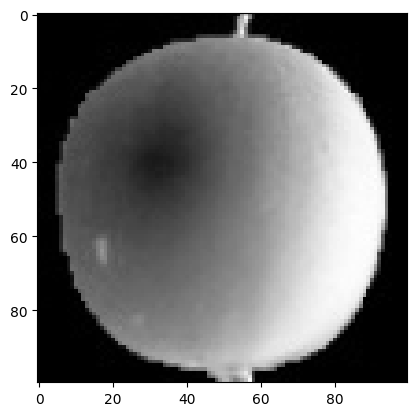

In [5]:
plt.imshow(fruits[0], cmap='gray')
plt.show()

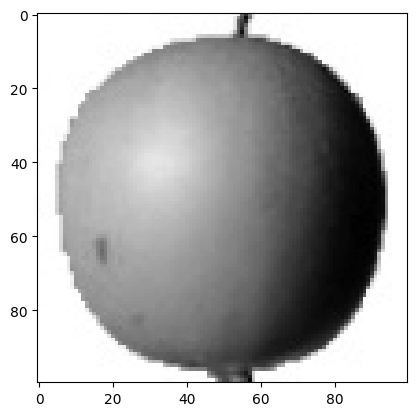

In [6]:
plt.imshow(fruits[0], cmap='gray_r') #흑백이미지를 반전, 배경을 흰색으로 추출
plt.show()

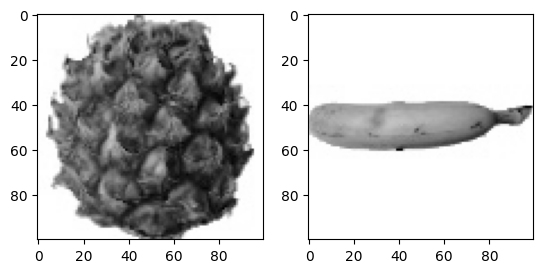

In [7]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(fruits[100], cmap='gray_r')
axs[1].imshow(fruits[200], cmap='gray_r')
plt.show()

In [8]:
apple = fruits[0:100].reshape(-1, 100*100)
pineapple = fruits[100:200].reshape(-1, 100*100) #1차원 배열로 이미지를 펼치는 과정
banana = fruits[200:300].reshape(-1, 100*100)
print(apple.shape)

(100, 10000)


In [9]:
print(apple.mean(axis=1))

[ 88.3346  97.9249  87.3709  98.3703  92.8705  82.6439  94.4244  95.5999
  90.681   81.6226  87.0578  95.0745  93.8416  87.017   97.5078  87.2019
  88.9827 100.9158  92.7823 100.9184 104.9854  88.674   99.5643  97.2495
  94.1179  92.1935  95.1671  93.3322 102.8967  94.6695  90.5285  89.0744
  97.7641  97.2938 100.7564  90.5236 100.2542  85.8452  96.4615  97.1492
  90.711  102.3193  87.1629  89.8751  86.7327  86.3991  95.2865  89.1709
  96.8163  91.6604  96.1065  99.6829  94.9718  87.4812  89.2596  89.5268
  93.799   97.3983  87.151   97.825  103.22    94.4239  83.6657  83.5159
 102.8453  87.0379  91.2742 100.4848  93.8388  90.8568  97.4616  97.5022
  82.446   87.1789  96.9206  90.3135  90.565   97.6538  98.0919  93.6252
  87.3867  84.7073  89.1135  86.7646  88.7301  86.643   96.7323  97.2604
  81.9424  87.1687  97.2066  83.4712  95.9781  91.8096  98.4086 100.7823
 101.556  100.7027  91.6098  88.8976]


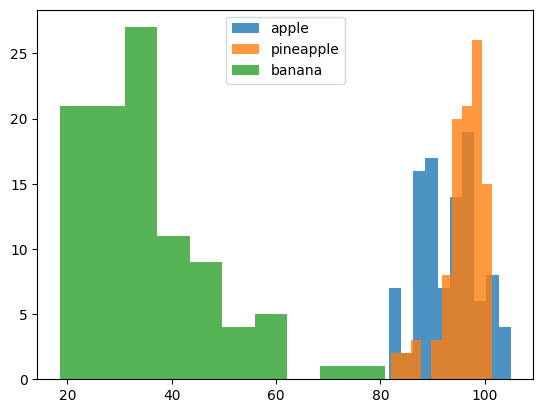

In [10]:
plt.hist(np.mean(apple, axis=1), alpha=0.8)
plt.hist(np.mean(pineapple, axis=1), alpha=0.8) #평균의 분포를 눈으로 확인하기 위해 히스토그램을 그림
plt.hist(np.mean(banana, axis=1), alpha=0.8)
plt.legend(['apple', 'pineapple', 'banana'])
plt.show()

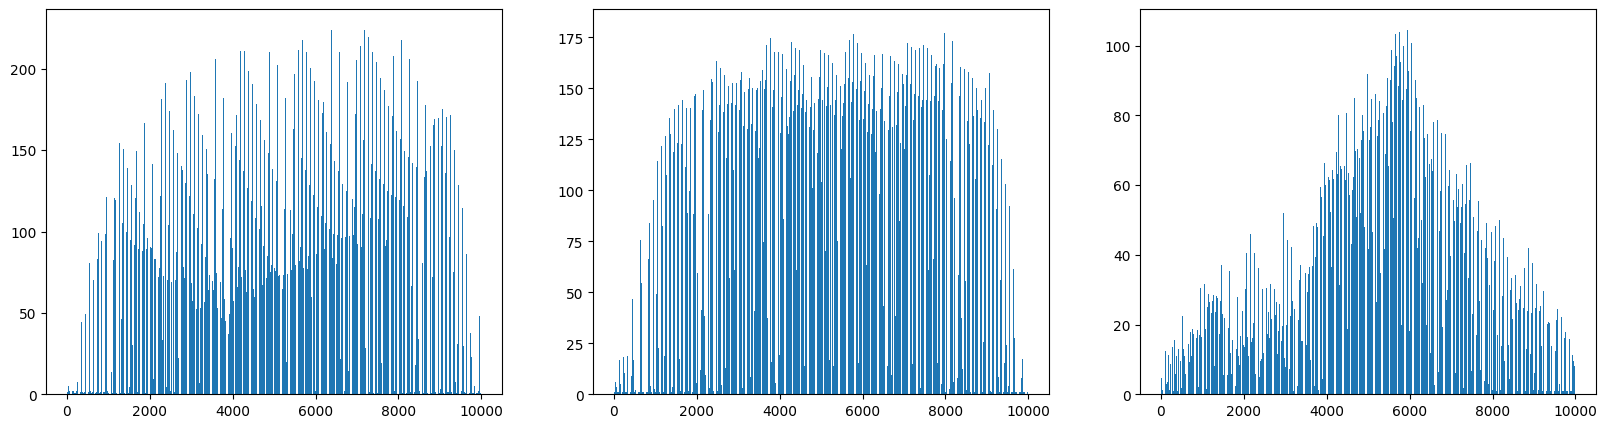

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5)) #샘플의 평균값이 아닌 픽셀의 평균값을 계산해보기
axs[0].bar(range(10000), np.mean(apple, axis=0))
axs[1].bar(range(10000), np.mean(pineapple, axis=0))
axs[2].bar(range(10000), np.mean(banana, axis=0))
plt.show()

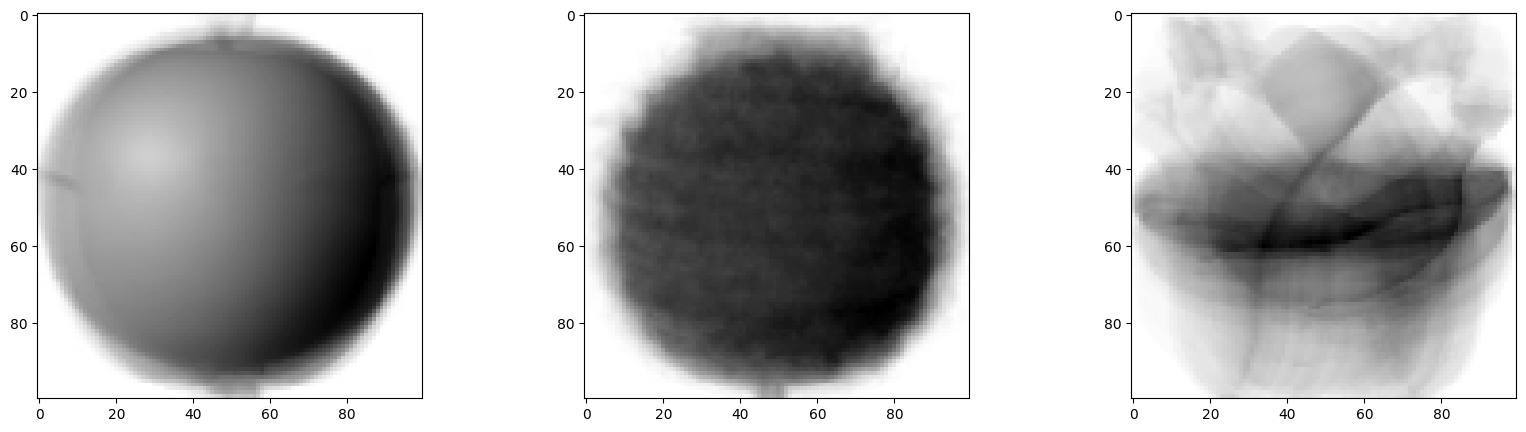

In [12]:
apple_mean = np.mean(apple, axis=0).reshape(100, 100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100, 100)
banana_mean = np.mean(banana, axis=0).reshape(100, 100)
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap='gray_r')
plt.show()

In [13]:
abs_diff = np.abs(fruits - apple_mean) #평균에 대한 절댓값 오차를 계산
abs_mean = np.mean(abs_diff, axis=(1,2))
print(abs_mean.shape)

(300,)


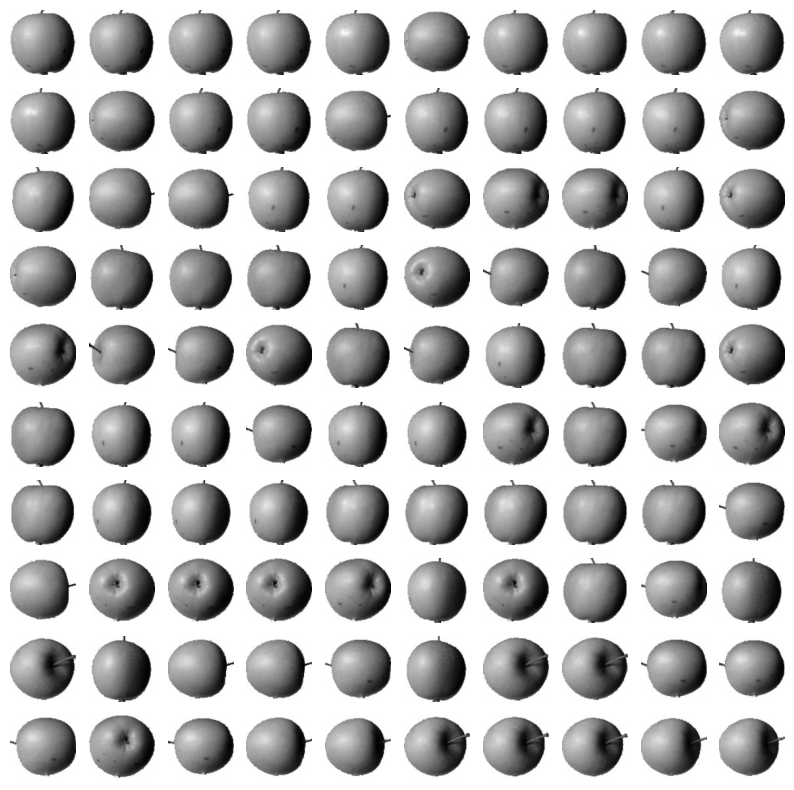

In [14]:
apple_index = np.argsort(abs_mean)[:100]  #오차가 가장 작은 100개를 계산에서 표현
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
  for j in range(10):
    axs[i, j].imshow(fruits[apple_index[i*10 + j]], cmap='gray_r')
    axs[i, j].axis('off')
plt.show()

# k-평균
## 평균값을 자동으로 찾아주는 군집 알고리즘

In [15]:
import numpy as np
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)


In [16]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42) #클러스터 개수가 3으로 지정하고 학습
km.fit(fruits_2d)
print(km.labels_)

[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [17]:
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [18]:
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1): # 3차원 배열을 입력받아 가로로 10개씩 이미지를 출력하는 함수
    n = len(arr)    # n은 샘플 개수입니다
    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))
    # 행이 1개 이면 열 개수는 샘플 개수입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:    # n 개까지만 그립니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()

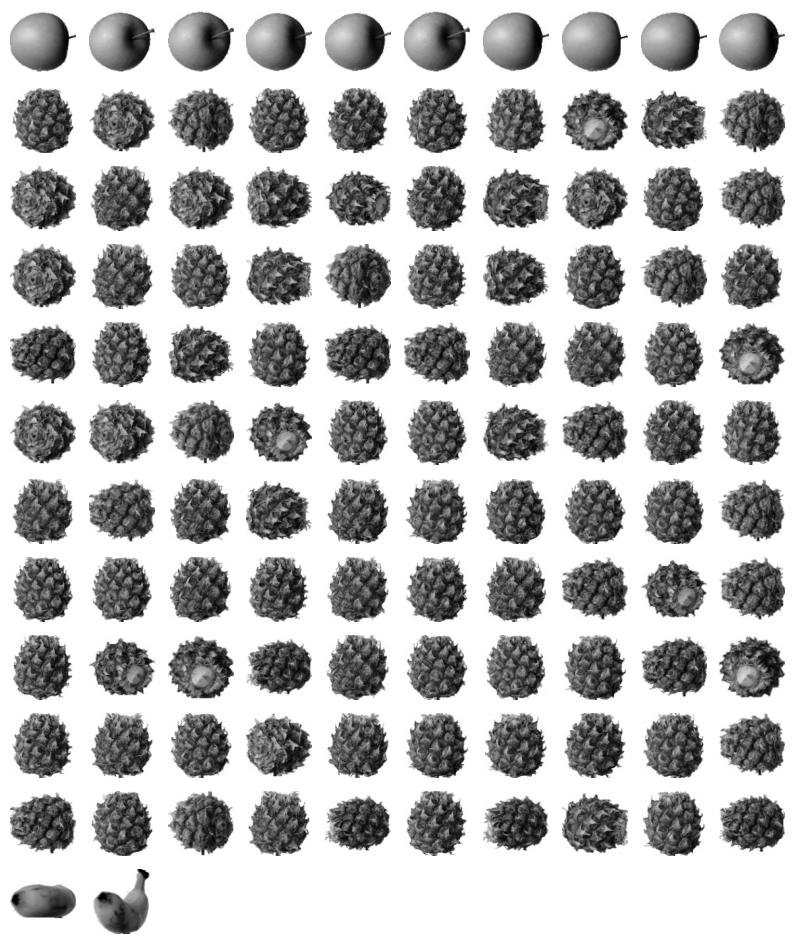

In [19]:
draw_fruits(fruits[km.labels_==0]) #불리언 인덱싱

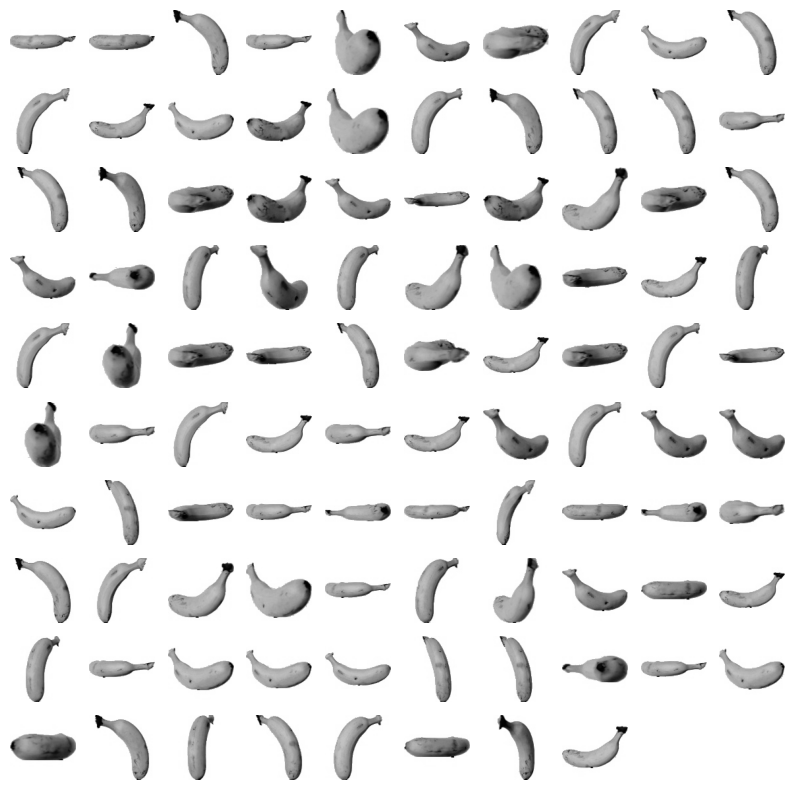

In [20]:
draw_fruits(fruits[km.labels_==1])

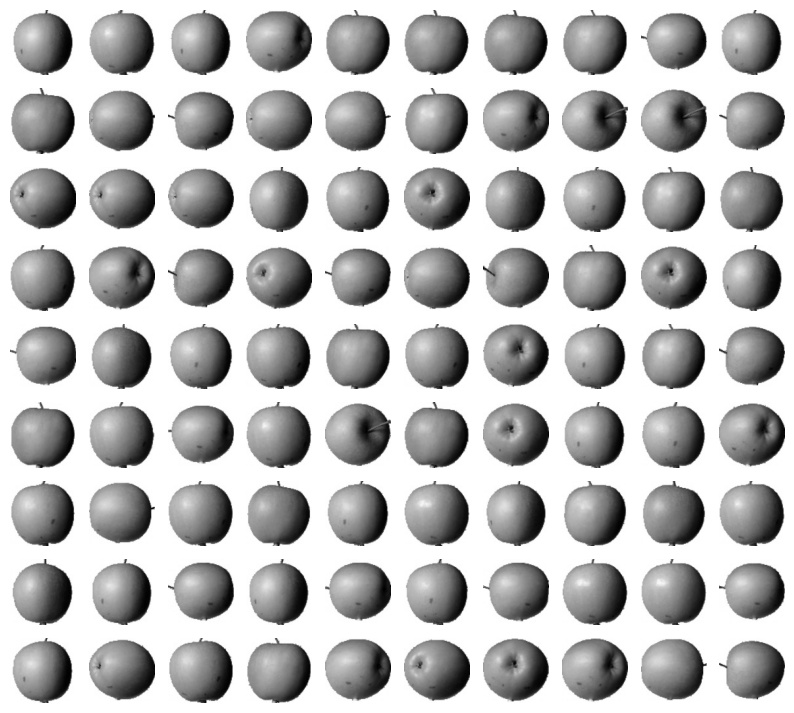

In [21]:
draw_fruits(fruits[km.labels_==2])

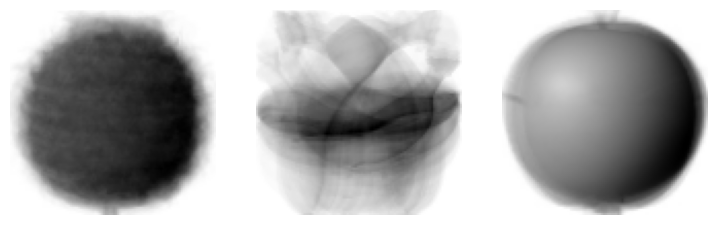

In [22]:
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3) # 클러스터 중심을 이미지로 출력

In [23]:
print(km.transform(fruits_2d[100:101]))

[[3400.24197319 8837.37750892 5279.33763699]]


In [24]:
print(km.predict(fruits_2d[100:101]))

[0]


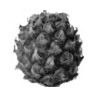

In [25]:
draw_fruits(fruits[100:101])

In [26]:
print(km.n_iter_)

4


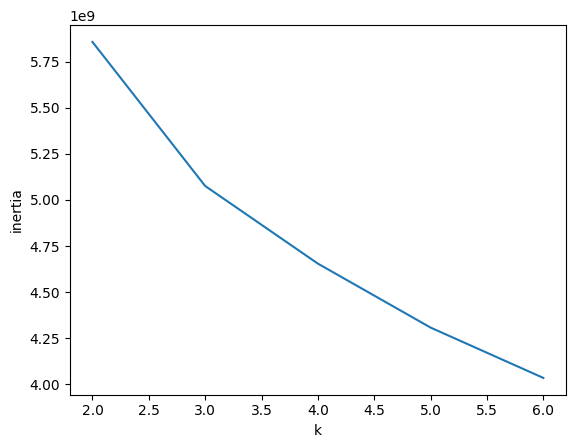

In [27]:
inertia = [] # 이너셔 : 클러스터에 속한 샘플들 사이의 거리의 제곱의 합
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_) #꺾이는 지점이 최적의 클러스터 개수가 될 것

plt.plot(range(2, 7), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50) # 주성분의 개수를 지정
pca.fit(fruits_2d)
print(pca.components_.shape)

(50, 10000)


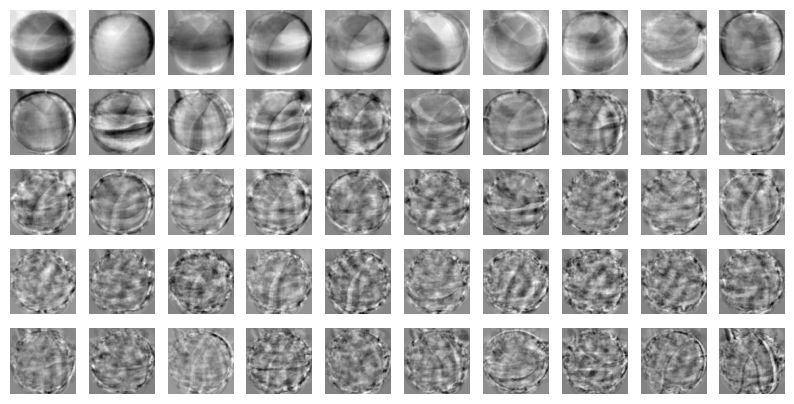

In [29]:
draw_fruits(pca.components_.reshape(-1, 100, 100)) # 주성분을 그림으로 그려보기

In [30]:
print(fruits_2d.shape)

(300, 10000)


In [31]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 50)


#원본 데이터 재구성 : 원본데이터로 복구해보기

In [32]:
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape) # 10000개의 특성을 복원

(300, 10000)


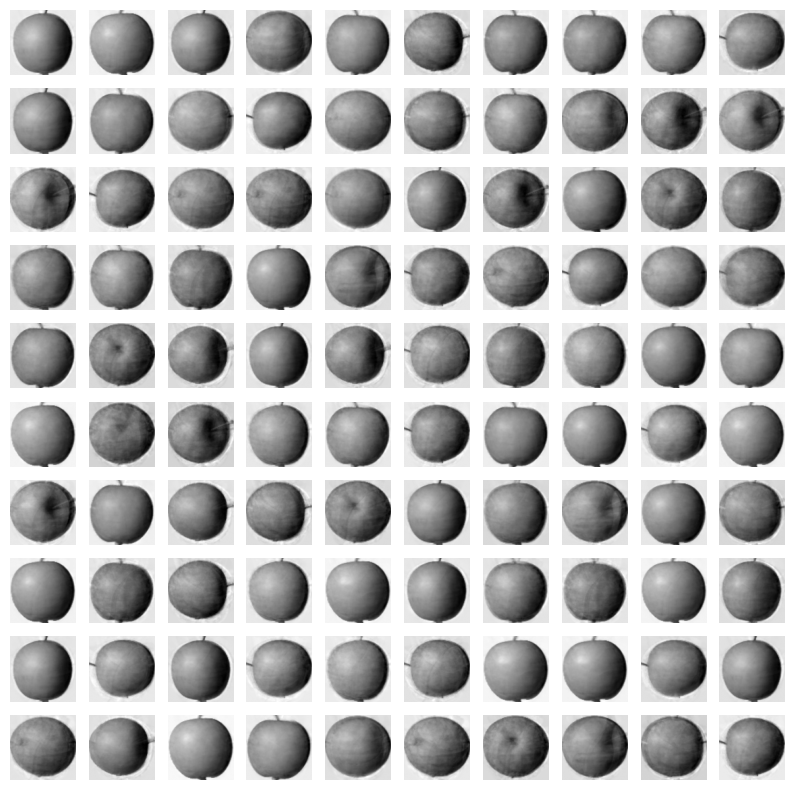

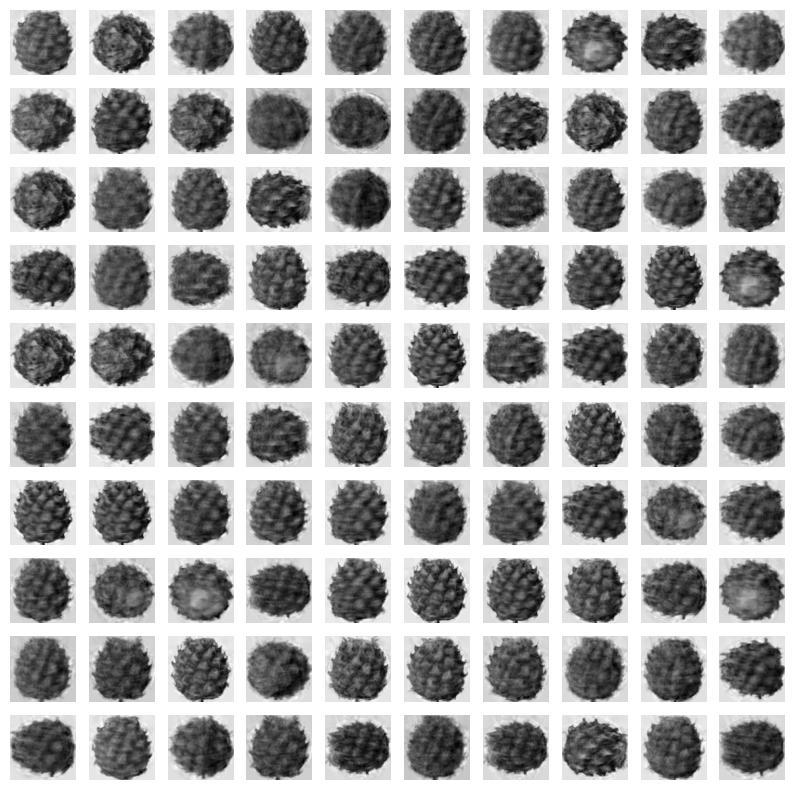

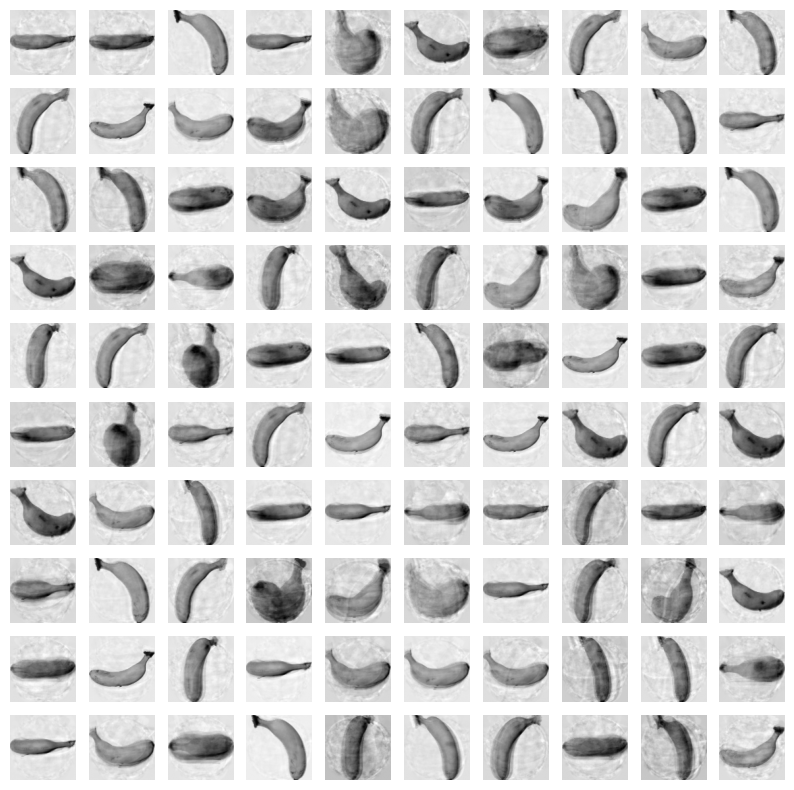

In [33]:
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print("\n")

#설명된 분산

In [34]:
print(np.sum(pca.explained_variance_ratio_)) # 주성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값

0.9215606116713683


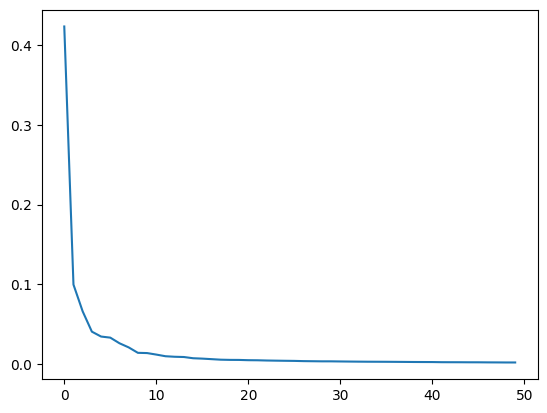

In [35]:
plt.plot(pca.explained_variance_ratio_) # 거의 초반 10개가 전부 표현을 하고 있다고도 볼 수 있다.

#다른 알고리즘과 함께 사용
## 로지스틱 회귀 모델 사용

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

target = np.array([0] * 100 + [1] * 100 + [2] * 100)

from sklearn.model_selection import cross_validate
scores = cross_validate(lr, fruits_2d, target) # 해당 모델의 성능을 가늠하기 위해 교차 검증 시행
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.6059705257415772


In [37]:
scores = cross_validate(lr, fruits_pca, target) # PCA로 축소한 값을 사용했을때
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time'])) # 시간이 감소하는 걸 볼 수 있다.

0.9966666666666667
0.020547771453857423


In [38]:
pca = PCA(n_components=0.5) # 설명된 분산의 0.5에 해당하는 components 변수에 해당하는 값을 찾음.
pca.fit(fruits_2d)
print(pca.n_components_)

2


In [39]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [40]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time'])) # 정확도와 시간을 확인

0.99
0.028971338272094728


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [41]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


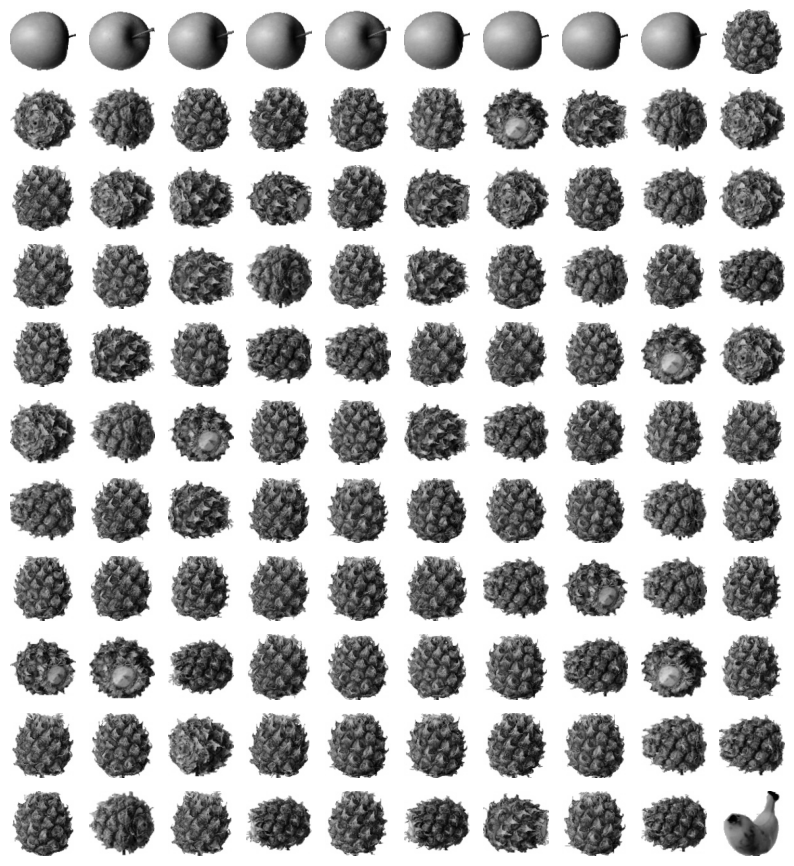

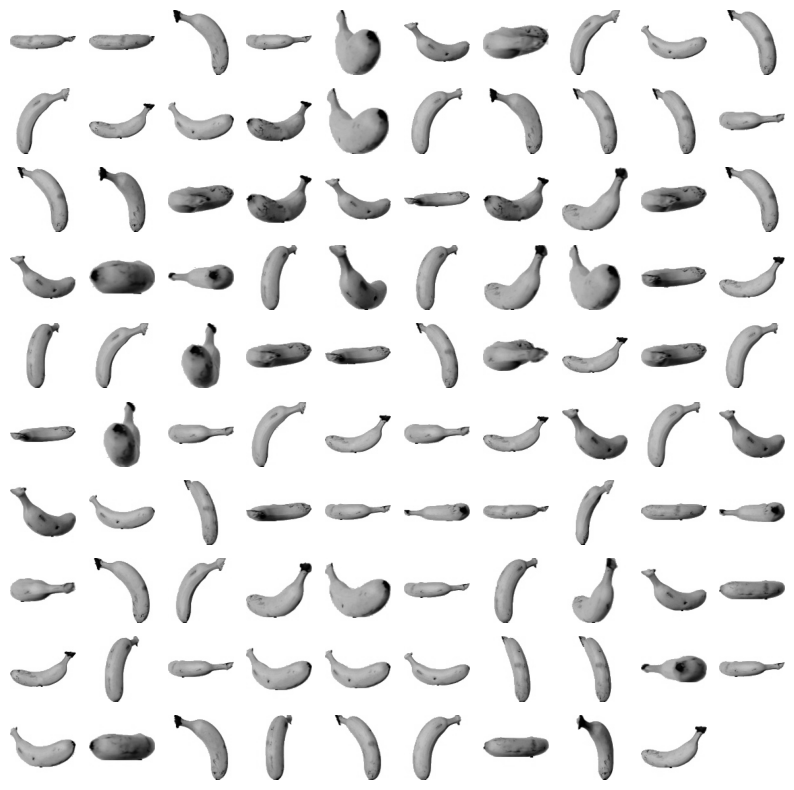

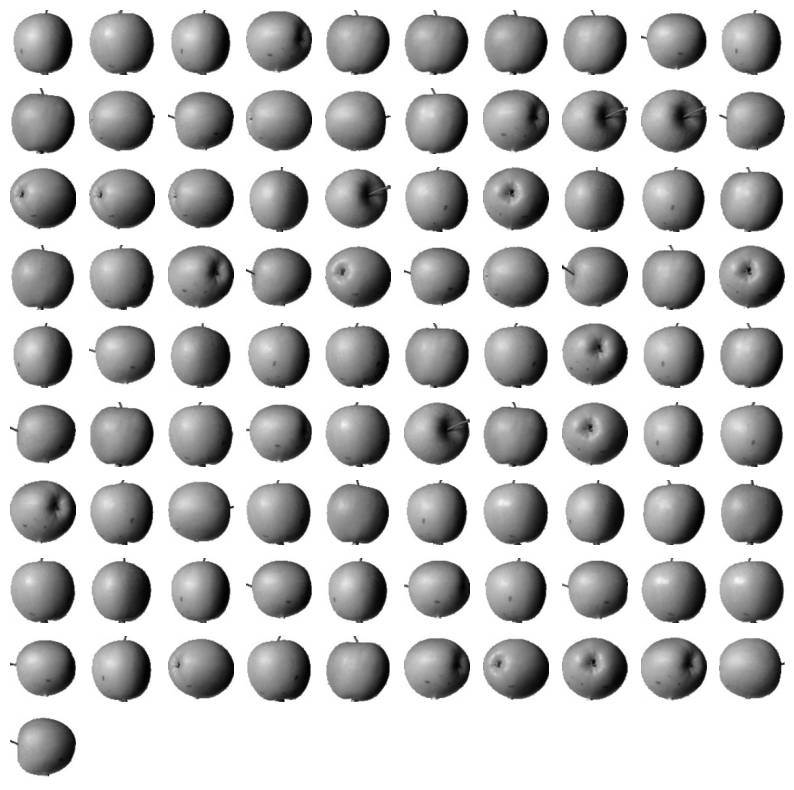

In [42]:
for label in range(0, 3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

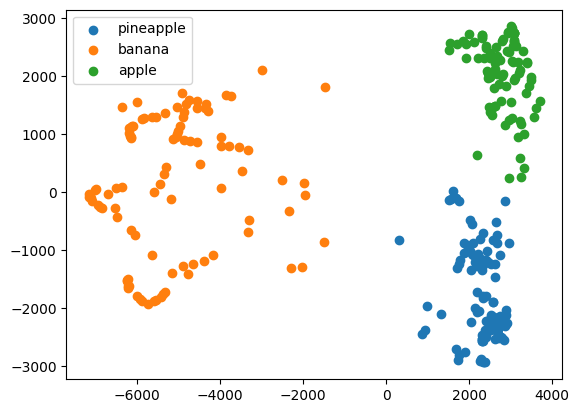

In [43]:
for label in range(0, 3):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:,0], data[:,1])
plt.legend(['pineapple', 'banana', 'apple'])
plt.show()

#과제 : 분산을 가장 크게 만드는 방향이 왜 공분산 행렬의 고유벡터가 될까?
1단계: PCA의 목적은 데이터를 어떤 축(벡터 $v$)에 투영시켰을 때, 데이터가 겹치지 않고 가장 넓게 퍼지는(분산이 최대가 되는) 방향을 찾는 것<br>

2단계: 투영된 데이터의 분산을 수학적으로 계산해 보면, 식 가운데에 자연스럽게 **공분산 행렬($\Sigma$)**이 들어간다.(수식: 분산 $\propto v^T \Sigma v$)<br>

3단계: 단, 방향을 나타내는 벡터 $v$의 길이를 무한대로 늘리면 분산도 덩달아 커집니다. 방향만 찾기 위해 벡터의 길이는 1로 고정한다는 약속을 한다.<br>

4단계: "길이가 1인 조건에서 분산을 최대로 만들어라"는 문제를 풀기 위해 미분(라그랑주 승수법)을 사용하면, **$\Sigma v = \lambda v$**라는 결과가 도출된다.<br>

5단계: 위에서 나온 결과식 **$\Sigma v = \lambda v$**는 선형대수학에서 말하는 '고유 벡터와 고유값의 정의' 그 자체이다.즉, 분산을 최대로 만드는 수학적 조건을 풀었더니, 그 답이 필연적으로 공분산 행렬의 고유 벡터가 된 것이다.